<a href="https://colab.research.google.com/github/Kuoz2/An-lisis_y_Predicci-n/blob/main/Regresion_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dk_casa= pd.read_csv("/content/drive/MyDrive/CURSOPYTHON/house-prices.csv")

In [2]:
dk_casa.head()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


In [3]:
dk_casa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Home          128 non-null    int64 
 1   Price         128 non-null    int64 
 2   SqFt          128 non-null    int64 
 3   Bedrooms      128 non-null    int64 
 4   Bathrooms     128 non-null    int64 
 5   Offers        128 non-null    int64 
 6   Brick         128 non-null    object
 7   Neighborhood  128 non-null    object
dtypes: int64(6), object(2)
memory usage: 8.1+ KB


In [4]:
dk_casa.describe()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers
count,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000
mean,64.500000,130427.343750,2000.937500,3.023438,2.445312,2.578125
std,37.094474,26868.770371,211.572431,0.725951,0.514492,1.069324
min,1.000000,69100.000000,1450.000000,2.000000,2.000000,1.000000
25%,32.750000,111325.000000,1880.000000,3.000000,2.000000,2.000000
50%,64.500000,125950.000000,2000.000000,3.000000,2.000000,3.000000
75%,96.250000,148250.000000,2140.000000,3.000000,3.000000,3.000000
max,128.000000,211200.000000,2590.000000,5.000000,4.000000,6.000000


In [5]:
dk_casa.tail(5)

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
123,124,119700,1900,3,3,3,Yes,East
124,125,147900,2160,4,3,3,Yes,East
125,126,113500,2070,2,2,2,No,North
126,127,149900,2020,3,3,1,No,West
127,128,124600,2250,3,3,4,No,North


In [6]:
display(dk_casa.isnull().sum())

,0
Home,0
Price,0
SqFt,0
Bedrooms,0
Bathrooms,0
Offers,0
Brick,0
Neighborhood,0


In [7]:
display(dk_casa.describe().round(2))

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers
count,128.00,128.00,128.00,128.00,128.00,128.00
mean,64.50,130427.34,2000.94,3.02,2.45,2.58
std,37.09,26868.77,211.57,0.73,0.51,1.07
min,1.00,69100.00,1450.00,2.00,2.00,1.00
25%,32.75,111325.00,1880.00,3.00,2.00,2.00
50%,64.50,125950.00,2000.00,3.00,2.00,3.00
75%,96.25,148250.00,2140.00,3.00,3.00,3.00
max,128.00,211200.00,2590.00,5.00,4.00,6.00


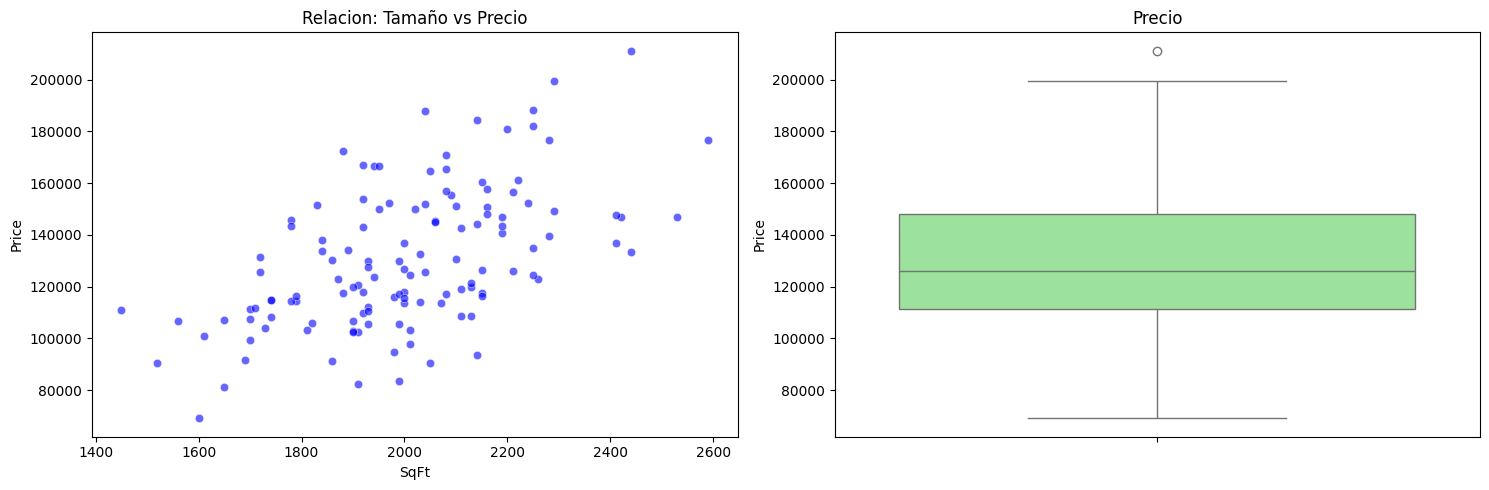

In [10]:
fig, axes= plt.subplots(1,2, figsize=(15,5))
sns.scatterplot(data=dk_casa, x='SqFt', y='Price', ax=axes[0], color='blue', alpha=0.6)
axes[0].set_title('Relacion: Tamaño vs Precio')
sns.boxplot(data=dk_casa['Price'], ax=axes[1], color='lightgreen')
axes[1].set_title('Precio')
plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [16]:
x=dk_casa[['SqFt','Bedrooms','Bathrooms']]
y=dk_casa['Price']

x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=42)
print(f"Datos de entrenamiento: {x_train.shape[0]} casas.")
print(f"Datos de prueba: {x_test.shape[0]} casas.")

Datos de entrenamiento: 102 casas.
Datos de prueba: 26 casas.


In [17]:
model_regr= LinearRegression()
model_regr.fit(x_train, y_train)

LinearRegression()

In [18]:
from sklearn.metrics import mean_squared_error, r2_score

predicciones_test= model_regr.predict(x_test)
mse= mean_squared_error(y_test, predicciones_test)
r2= r2_score(y_test, predicciones_test)
print("--- Evaluación del Modelo ---")
print(f"Error Cuadrático Medio (MSE): {mse:,.2f}")
print(f"R-cuadrado (R2): {r2:.4f}")
print("*(Nota: Un R2 más cercano a 1.0 indica un mejor ajuste del modelo)*")

--- Evaluación del Modelo ---
Error Cuadrático Medio (MSE): 320,149,938.23
R-cuadrado (R2): 0.4568
*(Nota: Un R2 más cercano a 1.0 indica un mejor ajuste del modelo)*


In [19]:
casa_nue= pd.DataFrame({'SqFt':[2000], 'Bedrooms':[3], 'Bathrooms':[2]})

preci_predi= model_regr.predict(casa_nue)
print(f"El precio estimado de la casa es: ${preci_predi[0]:,.2f}")

El precio estimado de la casa es: $123,537.00
